In [6]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("data.csv")

# reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [7]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [8]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes('object'):
    data[col] = LabelEncoder().fit_transform(data[col])

# CHANGE 'label' if needed
X = data.drop('label', axis=1)
y = data['label']

print("Preprocessing Done")

Preprocessing Done


In [9]:
# Scaling
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

pr = LinearRegression()
pr.fit(X_poly_train, y_train)
y_pred_pr = pr.predict(X_poly_test)

Linear Regression
MSE: 0.0136652562809757
R2: 0.9444741576606278

Polynomial Regression
MSE: 4.5524852157915845
R2: -17.49804871177416


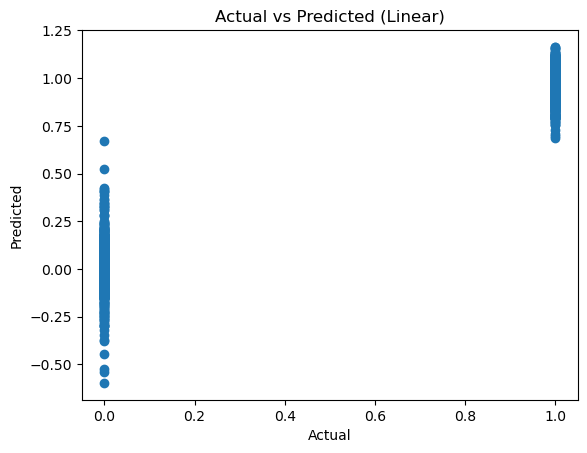

In [10]:
# Linear Regression Metrics
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

# Polynomial Regression Metrics
print("\nPolynomial Regression")
print("MSE:", mean_squared_error(y_test, y_pred_pr))
print("R2:", r2_score(y_test, y_pred_pr))

# Graph: Actual vs Predicted
plt.scatter(y_test, y_pred_lr)
plt.title("Actual vs Predicted (Linear)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()